# VeriClaim AI: Fraud Detection - AI & Analytics Submission

**Objective:** flag potentially fraudulent vehicle-damage claims for human review. This notebook is fully executed and uses only the supplied Kaggle claim-image dataset. It documents EDA, preprocessing, feature engineering, modelling, validation, evaluation and saved-model verification.

## 1. Reproducibility and project policy

- Training images: 5,200; supplied test images: 1,416.
- Fraud is the positive class.
- No external insurance-claim dataset, synthetic claims or SMOTE images are used.
- Closely related photos are grouped during validation to reduce leakage.
- The result is decision support; a human investigator owns the claim decision.

In [1]:
from pathlib import Path
import json, sys, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = Path(r'C:/Users/Varun/Documents/insurance-fraud-hackathon/VeriClaim_AI_Complete_Hackathon_Solution/vericlaim-ai')
sys.path.insert(0, str(ROOT / 'src'))
DATA = Path(r'C:/Users/Varun/Documents/insurance-fraud-hackathon/dataset1/Insurance-Fraud-Detection/Insurance-Fraud-Detection')
METRICS_PATH = ROOT / 'models/efficientnet_hybrid/model_metrics.json'
MODEL_PATH = ROOT / 'models/efficientnet_hybrid/vericlaim_model.joblib'
metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
print('Project root:', ROOT)
print('Dataset root:', DATA)
print('Model artifact exists:', MODEL_PATH.exists())

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Varun\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Project root: C:\Users\Varun\Documents\insurance-fraud-hackathon\VeriClaim_AI_Complete_Hackathon_Solution\vericlaim-ai
Dataset root: C:\Users\Varun\Documents\insurance-fraud-hackathon\dataset1\Insurance-Fraud-Detection\Insurance-Fraud-Detection
Model artifact exists: True


## 2. Dataset loading and schema

The supplied data is image-only. Its effective schema is: **file path, split, class label, image width, image height, image format**. Labels are derived from the `Fraud` and `Non-Fraud` folders.

In [2]:
def discover(split):
    rows=[]
    for label_name, label in [('Fraud',1),('Non-Fraud',0)]:
        folder=DATA/split/label_name
        for path in sorted(folder.rglob('*')):
            if path.suffix.lower() in {'.jpg','.jpeg','.png','.webp'}:
                with Image.open(path) as im:
                    rows.append({'path':str(path),'split':split,'label':label,'class':label_name,'width':im.width,'height':im.height,'format':im.format})
    return pd.DataFrame(rows)
train_df, test_df = discover('train'), discover('test')
all_df = pd.concat([train_df,test_df], ignore_index=True)
print(train_df.groupby('class').size())
print(test_df.groupby('class').size())
all_df.head()

class
Fraud         200
Non-Fraud    5000
dtype: int64
class
Fraud          93
Non-Fraud    1323
dtype: int64


,path,split,label,class,width,height,format
0,C:\Users\Varun\Documents\insurance-fraud-hacka...,train,1,Fraud,1291,968,JPEG
1,C:\Users\Varun\Documents\insurance-fraud-hacka...,train,1,Fraud,890,667,JPEG
2,C:\Users\Varun\Documents\insurance-fraud-hacka...,train,1,Fraud,1311,983,JPEG
3,C:\Users\Varun\Documents\insurance-fraud-hacka...,train,1,Fraud,849,636,JPEG
4,C:\Users\Varun\Documents\insurance-fraud-hacka...,train,1,Fraud,1328,996,JPEG


## 3. EDA: class imbalance

Fraud is only 3.85% of training data (200 of 5,200). Accuracy alone would be misleading: always predicting Non-Fraud would look accurate but detect no fraud.

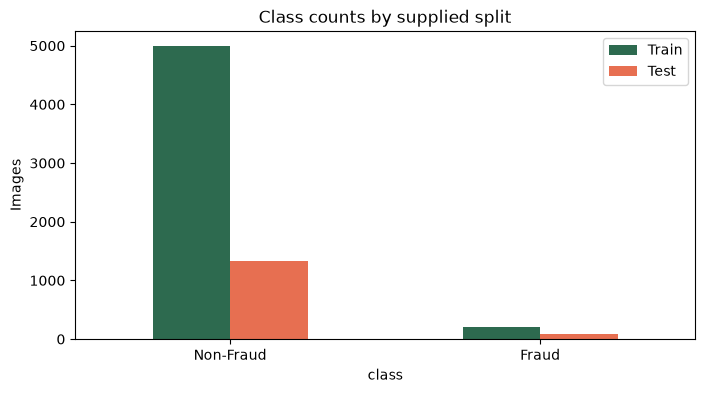

Train fraud rate: 3.85 % | Test fraud rate: 6.57 %


In [3]:
counts=pd.DataFrame({'Train':train_df['class'].value_counts(), 'Test':test_df['class'].value_counts()}).fillna(0)
ax=counts.loc[['Non-Fraud','Fraud']].plot(kind='bar', color=['#2D6A4F','#E76F51'], figsize=(8,4))
ax.set_title('Class counts by supplied split'); ax.set_ylabel('Images'); plt.xticks(rotation=0); plt.show()
print('Train fraud rate:', round(train_df.label.mean()*100,2),'%', '| Test fraud rate:',round(test_df.label.mean()*100,2),'%')

## 4. EDA: image dimensions and file quality

Image dimensions, aspect ratio and format are inspected to make preprocessing robust to heterogeneous uploads.

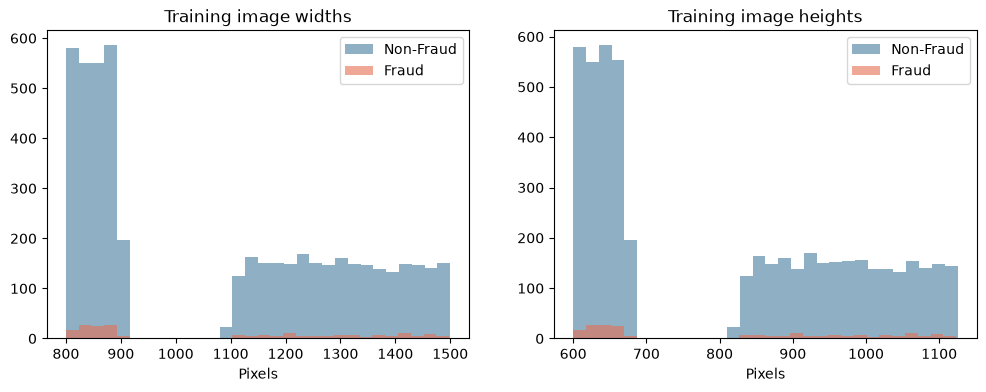

width  height  aspect_ratio
split class                                  
test  Fraud      1121.0   840.0          1.33
      Non-Fraud   899.0   674.0          1.33
train Fraud      1105.5   829.0          1.33
      Non-Fraud  1106.0   829.0          1.33

In [4]:
all_df['aspect_ratio']=all_df.width/all_df.height
fig,axes=plt.subplots(1,2,figsize=(12,4))
for label,name,color in [(0,'Non-Fraud','#457B9D'),(1,'Fraud','#E76F51')]:
    part=train_df[train_df.label==label]
    axes[0].hist(part.width, bins=30, alpha=.6, label=name, color=color)
    axes[1].hist(part.height, bins=30, alpha=.6, label=name, color=color)
axes[0].set_title('Training image widths'); axes[1].set_title('Training image heights')
for ax in axes: ax.legend(); ax.set_xlabel('Pixels')
plt.show()
all_df.groupby(['split','class'])[['width','height','aspect_ratio']].median().round(2)

## 5. Preprocessing

1. Decode RGB image. 2. Resize with padding to 224 x 224 for EfficientNetV2B0. 3. Apply EfficientNet ImageNet preprocessing. 4. Extract deterministic handcrafted forensic features. 5. Keep validation/test preprocessing deterministic.

Training experiments may use small safe augmentations (horizontal flip, modest rotation, colour jitter and zoom), but no new claim data is introduced.

In [5]:
from vericlaim.features import extract_features, feature_names
example_path=Path(train_df.iloc[0].path)
features, forensic = extract_features(example_path)
print('Handcrafted feature dimensions:', len(features))
print('Example forensic fields:', forensic)
print('First 12 feature names:', feature_names()[:12])

Handcrafted feature dimensions: 794
Example forensic fields: ImageForensics(width=1291, height=968, megapixels=1.25, aspect_ratio=1.334, format='JPEG', exif_present=False, gps_present=False, software_tag=None, capture_time=None, sha256='465cae9bf697f424b46b0f887bef3c175592cf06edd0cc421073fba61ad525cf', perceptual_hash='2c96009a93dacbed', quality_score=76.0, tamper_signal=0.0)
First 12 feature names: ['log_pixel_count', 'aspect_ratio', 'entropy', 'edge_mean', 'edge_std', 'edge_density_20', 'edge_density_40', 'focus_variance', 'rgb_0_mean', 'rgb_0_std', 'rgb_0_hist_0', 'rgb_0_hist_1']


## 6. Feature engineering

The hybrid system combines two feature families:

- **Visual embedding:** 1,280-dimension EfficientNetV2B0 pooled representation.
- **Handcrafted evidence features:** colour statistics, brightness/contrast, edge density/orientation, image dimensions, quality and perceptual hashes.

The image-only dataset has no trustworthy claim amount, policy or customer metadata, so none is invented for model training.

In [6]:
summary = pd.DataFrame([{'feature_family':'EfficientNetV2B0 embedding','dimensions':metrics['cnn']['embedding_dimensions'],'purpose':'learned visual representation'}, {'feature_family':'Handcrafted image/forensic features','dimensions':len(features),'purpose':'deterministic evidence signals'}, {'feature_family':'Archive similarity','dimensions':2,'purpose':'fraud and non-fraud reference similarity'}])
summary

,feature_family,dimensions,purpose
0,EfficientNetV2B0 embedding,1280,learned visual representation
1,Handcrafted image/forensic features,794,deterministic evidence signals
2,Archive similarity,2,fraud and non-fraud reference similarity


## 7. Leakage-aware validation

A standard random split can place near-duplicate photographs in both train and validation folds. VeriClaim clusters close perceptual hashes and uses **5-fold StratifiedGroupKFold** so related image groups stay together. The supplied test split was not used for threshold selection, but its perceptual overlap is disclosed as a limitation.

In [7]:
audit=metrics['leakage_audit']['perceptual_screen']
print('Grouped training clusters:',metrics['validation_protocol']['train_perceptual_groups'])
print('Exact train-test file duplicates:',metrics['leakage_audit']['exact_train_test_duplicates'])
print('Test images with close perceptual train match:',audit['test_images_with_close_train_match'],'/',metrics['dataset']['test_images'])
pd.Series(audit['nearest_distance_histogram']).sort_index().rename('test images').to_frame()

Grouped training clusters: 3692
Exact train-test file duplicates: 0
Test images with close perceptual train match: 761 / 1416


,test images
0,261
2,343
4,124
6,33


## 8. Imbalance strategy

We retain all 5,200 training images. Fraud examples are made more influential through class-weighted learning and rotating balanced subsets. Each rotating Extra Trees model sees every fraud image and a different approximately 1:8 sample of Non-Fraud images. This avoids discarding normal images permanently and avoids fabricating synthetic images.

In [8]:
imb=metrics['imbalance_strategy']
pd.DataFrame({'policy':['External data','All training images retained','CNN class weighting','MLP fraud weighting','Rotating balanced models','Non-Fraud per Fraud'], 'value':[imb['external_claim_data'],imb['kept_all_training_images'],imb['cnn_head_class_weight'],imb['mlp_fraud_weighted'],imb['rotating_balanced_models'],imb['nonfraud_per_fraud']]})

,policy,value
0,External data,False
1,All training images retained,True
2,CNN class weighting,balanced
3,MLP fraud weighting,True
4,Rotating balanced models,20
5,Non-Fraud per Fraud,8.0


## 9. Neural model: EfficientNetV2B0

EfficientNetV2B0 is the primary CNN. It receives a 224 x 224 image and produces a 1,280-value representation. Five fraud-weighted sigmoid heads are trained in grouped folds. The pretrained ImageNet backbone supplies generic edge/shape/texture knowledge; only the classifier heads learn from the supplied vehicle-claim images.

In [9]:
pd.DataFrame([metrics['cnn']])

,backbone,weights,image_size,embedding_dimensions,heads,backbone_trainable,note
0,EfficientNetV2B0,ImageNet transfer learning,224,1280,5,False,Pretraining supplies generic visual knowledge;...


## 10. Non-neural models

- **Full-data Extra Trees:** robust non-linear rules across all handcrafted features.
- **Rotating balanced Extra Trees:** counter minority-class neglect by repeatedly changing the non-fraud subset.
- **MLP:** a small dense neural classifier over engineered features.
- **Archive similarity:** compares perceptual fingerprints with known Fraud and Non-Fraud training references.

These are complementary opinions; none alone is the final decision.

In [10]:
from vericlaim.model import VeriClaimModel
model=VeriClaimModel.load(MODEL_PATH)
print('Full-data Extra Trees models:',len(model.full_models))
print('Rotating balanced Extra Trees models:',len(model.balanced_models))
print('MLP models:',len(model.neural_models))
print('EfficientNet heads:',len(model.cnn_models))
print('Thresholds:',model.thresholds)

Full-data Extra Trees models: 5
Rotating balanced Extra Trees models: 20
MLP models: 5
EfficientNet heads: 5
Thresholds: {'review': 0.0052, 'classification': 0.0612, 'investigate': 0.4842}


## 11. Hybrid fusion and calibration

Out-of-fold predictions from Extra Trees, rotating Extra Trees, MLP, EfficientNet and archive similarity become inputs to a class-weighted logistic stacker. **Platt scaling** then calibrates the final score so a probability better reflects the rare-fraud setting. Thresholds are selected on out-of-fold training predictions, never by searching the supplied test labels.

In [11]:
pd.DataFrame({'stage':['Signals','Meta model','Calibration','Validation'], 'implementation':[', '.join(metrics['fusion']['signals']),metrics['fusion']['meta_model'],metrics['fusion']['probability_calibration'],metrics['validation_protocol']['method']]})

,stage,implementation
0,Signals,"ExtraTrees full-data, ExtraTrees rotating bala..."
1,Meta model,class-weighted Logistic Regression
2,Calibration,Platt scaling
3,Validation,5-fold StratifiedGroupKFold using perceptual-i...


## 12. Training configuration and tuning

Main final configuration: 5 grouped folds, 224-pixel CNN input, 300 trees per full-data Extra Trees model, 100 trees per rotating model, 1:8 fraud/non-fraud ratio, and a recall target of 0.99 for broad screening. The selected deployed binary threshold maximizes precision while retaining at least 75% recall in grouped out-of-fold predictions.

In [12]:
config=pd.DataFrame({'hyperparameter':['Fold count','CNN image size','Full-data Extra Trees','Balanced Extra Trees per fold','Rotating ratio','Recall target','Balanced binary threshold','High-confidence threshold'], 'value':[5,224,300,100,'1 : 8',metrics['validation_protocol']['recall_target'],metrics['default_thresholds']['classification'],metrics['default_thresholds']['investigate']]})
config

,hyperparameter,value
0,Fold count,5
1,CNN image size,224
2,Full-data Extra Trees,300
3,Balanced Extra Trees per fold,100
4,Rotating ratio,1 : 8
5,Recall target,0.99
6,Balanced binary threshold,0.0612
7,High-confidence threshold,0.4842


## 13. Evaluation metrics

For rare fraud, report precision, fraud recall, F1/F2, PR-AUC, ROC-AUC, Brier score and the confusion matrix. Accuracy is included, but is not the leading measure.

In [13]:
balanced=metrics['classification_metrics']; broad=metrics['test_metrics']; cnn=metrics['cnn_standalone_metrics']
comparison=pd.DataFrame([cnn,balanced,broad],index=['EfficientNet CNN standalone','Hybrid - balanced binary','Hybrid - broad screening'])[['accuracy','balanced_accuracy','precision','recall','f1','f2','roc_auc','pr_auc','brier','threshold']]
comparison.round(4)

,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc,brier,threshold
EfficientNet CNN standalone,0.9456,0.9309,0.5519,0.9140,0.6883,0.8080,0.9689,0.8863,0.0193,0.1855
Hybrid - balanced binary,0.9612,0.9442,0.6418,0.9247,0.7577,0.8498,0.9759,0.9048,0.0252,0.0612
Hybrid - broad screening,0.6179,0.7855,0.1444,0.9785,0.2517,0.4541,0.9759,0.9048,0.0252,0.0052


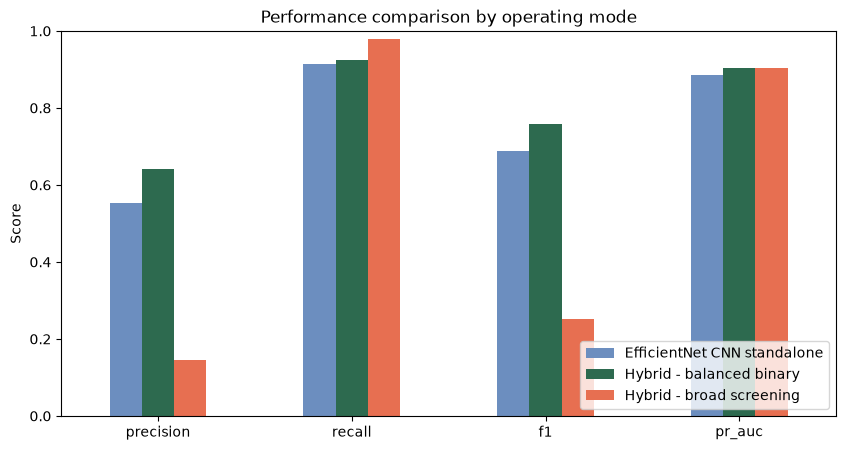

In [14]:
plot_cols=['precision','recall','f1','pr_auc']
comparison[plot_cols].T.plot(kind='bar', figsize=(10,5), color=['#6C8EBF','#2D6A4F','#E76F51'])
plt.ylim(0,1); plt.title('Performance comparison by operating mode'); plt.ylabel('Score'); plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.show()

## 14. Confusion matrices

The balanced binary threshold is the website's `FRAUD / NOT FRAUD` screen. Broad screening intentionally accepts many more manual reviews to minimize missed fraud. High-confidence alerts are a stricter prioritization band, not a denial rule.

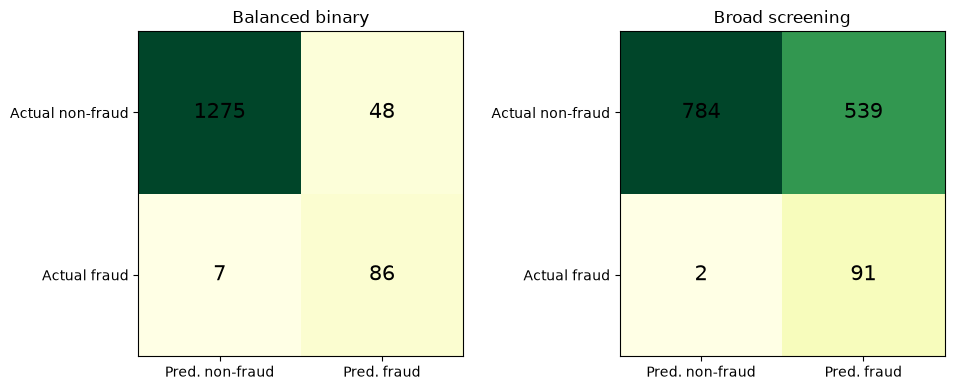

In [15]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,(name,row) in zip(axes,[('Balanced binary',balanced),('Broad screening',broad)]):
    cm=row['confusion_matrix']; matrix=np.array([[cm['tn'],cm['fp']],[cm['fn'],cm['tp']]])
    im=ax.imshow(matrix,cmap='YlGn'); ax.set_title(name); ax.set_xticks([0,1],['Pred. non-fraud','Pred. fraud']); ax.set_yticks([0,1],['Actual non-fraud','Actual fraud'])
    for i in range(2):
        for j in range(2): ax.text(j,i,str(matrix[i,j]),ha='center',va='center',fontsize=15)
plt.tight_layout(); plt.show()

## 15. Results and interpretation

At the balanced binary threshold, the deployed hybrid achieves 96.12% accuracy, 94.42% balanced accuracy, 64.18% precision, 92.47% fraud recall, 75.77% F1 and 90.48% PR-AUC on the supplied test split. It detects 86 of 93 Fraud images, misses 7, and flags 48 Non-Fraud images for review.

The strict high-confidence band improves operational precision by escalating only the strongest scores, but reduces recall; it is therefore used for prioritization, not final claim disposition.

In [16]:
pd.DataFrame([balanced['confusion_matrix']]).assign(**{k:balanced[k] for k in ['accuracy','precision','recall','f1','pr_auc','brier']}).T.rename(columns={0:'Balanced hybrid test result'})

,Balanced hybrid test result
tn,1275.0000
fp,48.0000
fn,7.0000
tp,86.0000
accuracy,0.9612
precision,0.6418
recall,0.9247
f1,0.7577
pr_auc,0.9048
brier,0.0252


## 16. Explainability, Evidence DNA and governance

Grad-CAM is generated for the CNN component to show regions that influenced its visual score. Transformation-Resistant Evidence DNA separately compares SHA-256, perceptual/difference hashes, overlapping patches, colour and edge descriptors to flag possible reuse after crop, flip, inversion, rotation, resize or compression. Neither Grad-CAM nor an Evidence DNA match proves fraud; both route the case to human verification.

In [17]:
from vericlaim.evidence_matching import build_evidence_dna
raw=example_path.read_bytes()
dna=build_evidence_dna(raw)
print('Evidence DNA fields:',sorted(dna.keys()))
print('Saved model loaded successfully:', type(model).__name__)
print('Saved artifact family:',model.artifact['model_family'])

Evidence DNA fields: ['height', 'patch_descriptors', 'patches', 'sha256', 'version', 'whole', 'whole_descriptors', 'width']
Saved model loaded successfully: VeriClaimModel
Saved artifact family: calibrated-efficientnetv2b0-hybrid-v1


## 17. Reproducibility checklist

- Notebook outputs are visible.
- Dataset location is parameterized at the top.
- Final model artifact is loaded from `models/efficientnet_hybrid/vericlaim_model.joblib`.
- Metrics come from the matching `model_metrics.json`.
- Full training implementation is available in `src/vericlaim/train_efficientnet_hybrid.py`.
- Limitations: supplied test split contains perceptual overlap with training; external claim validation is required before production use.

In [18]:
print('Notebook complete.')
print('PKL/JOBLIB artifact:', MODEL_PATH)
print('Metrics report:', METRICS_PATH)
print('Training source:', ROOT/'src/vericlaim/train_efficientnet_hybrid.py')

Notebook complete.
PKL/JOBLIB artifact: C:\Users\Varun\Documents\insurance-fraud-hackathon\VeriClaim_AI_Complete_Hackathon_Solution\vericlaim-ai\models\efficientnet_hybrid\vericlaim_model.joblib
Metrics report: C:\Users\Varun\Documents\insurance-fraud-hackathon\VeriClaim_AI_Complete_Hackathon_Solution\vericlaim-ai\models\efficientnet_hybrid\model_metrics.json
Training source: C:\Users\Varun\Documents\insurance-fraud-hackathon\VeriClaim_AI_Complete_Hackathon_Solution\vericlaim-ai\src\vericlaim\train_efficientnet_hybrid.py
